# Fichero `adult.csv` — Preparación de datos y modelo supervisado

Este notebook reúne **todo lo trabajado** hasta ahora:
1. Carga del dataset `adult.csv`
2. Creación del **dataset reducido** (solo columnas objetivo)
3. Limpieza de valores ausentes (`?` → `NaN`) y eliminación de filas incompletas
4. Definición de **X** e **y** (objetivo: `income`)
5. Identificación de variables **numéricas** y **categóricas**
6. Preprocesado con **ColumnTransformer** (StandardScaler + OneHotEncoder)
7. División **train/test**
8. Entrenamiento de un **modelo** (Regresión Logística)
9. Evaluación básica (classification report + matriz de confusión)



## 1. Carga del dataset

Nos aseguramos de que `adult.csv` está en la misma carpeta que este notebook.

## 2. Creación del dataset reducido (solo columnas objetivo)
**Variables que se conservarán (las únicas permitidas en la práctica):**

Las variables que unicamente necesitaremos serian: age, workclass, education, education.num, occupation, race, sex, 
capital.gain, capital.loss, hours.per.week, income.

## 3. Limpieza del dataset reducido

En adult.csv, los valores ausentes a veces aparecen como `?` en algunas columnas, como podemos ver en la celda anterior
- Sustituimos `?` por `NaN`
- Comprobamos nulos por columna


In [17]:
import pandas as pd

df_adultos = pd.read_csv("../EjDatos/adult.csv")
df_adultos.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [18]:
df_filtrado = df_adultos[["age", "workclass", "education", "education.num", "occupation", "race", "sex", "capital.gain", "capital.loss", "hours.per.week", "income"]]
df_filtrado.head()

,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,?,HS-grad,9,?,White,Female,0,4356,40,<=50K
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,<=50K
2,66,?,Some-college,10,?,Black,Female,0,4356,40,<=50K
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,<=50K
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,<=50K


In [19]:
import numpy as np

df_filtrado.replace("?", np.nan, inplace=True)
df_filtrado.head()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20940\2737496038.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.replace("?", np.nan, inplace=True)


,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,NaN,HS-grad,9,NaN,White,Female,0,4356,40,<=50K
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,<=50K
2,66,NaN,Some-college,10,NaN,Black,Female,0,4356,40,<=50K
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,<=50K
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,<=50K


## 4. Definir el problema supervisado: predicción de salario (`income`)

Averiguar las personas que cobran mas de 50k o menos.

## 5. Identificación de variables numéricas y categóricas

De lo anterior vemos que hay:
- variables numéricas: age, education.num, sapital.gain, capital.loss, hours.per.week, income.
- variables categóricas: workclass, education, occupation, race, sex.

### Preprocesado de los datos

En esta fase se preparan las variables para su uso en el modelo de Machine Learning.
Dado que el conjunto de datos contiene variables numéricas y categóricas, se aplican
técnicas de preprocesado diferenciadas, incluyendo la imputación de valores nulos,
el escalado de variables numéricas y la codificación de variables categóricas mediante
One-Hot Encoding.


## 6. Preprocesado con sklearn

Ahora terminamos de preparar todo

In [20]:
df_filtrado_income = df_filtrado.copy()

df_filtrado_income["income"].replace({
    ">50K": 1,
    "<=50K": 0
}, inplace=True)

df_filtrado_income.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20940\734793899.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtrado_income["income"].replace({
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20940\734793899.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filtrado_income["income"].repl

,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,NaN,HS-grad,9,NaN,White,Female,0,4356,40,0
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,0
2,66,NaN,Some-college,10,NaN,Black,Female,0,4356,40,0
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,0
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df_filtrado_income[["age", "capital.gain", "capital.loss", "hours.per.week"]]
y = df_filtrado_income["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

## 7. División en entrenamiento y prueba

### Entrenamiento del modelo

Una vez definidos el conjunto de entrenamiento y el preprocesado de los datos,
se procede al entrenamiento de un modelo de clasificación basado en regresión logística,
utilizado como modelo base para este problema.


In [22]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 8. Regresión


### Evaluación del modelo

El rendimiento del modelo se evalúa utilizando distintas métricas de clasificación,
así como la matriz de confusión, con el objetivo de analizar su capacidad predictiva
y detectar posibles limitaciones.


In [23]:
y_pred = log_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2: ", r2)
print("MAE: ", mae)
print("MSE: ", mse)

R2:  -0.12494076969584111
MAE:  0.20282511899278366
MSE:  0.20282511899278366


In [24]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

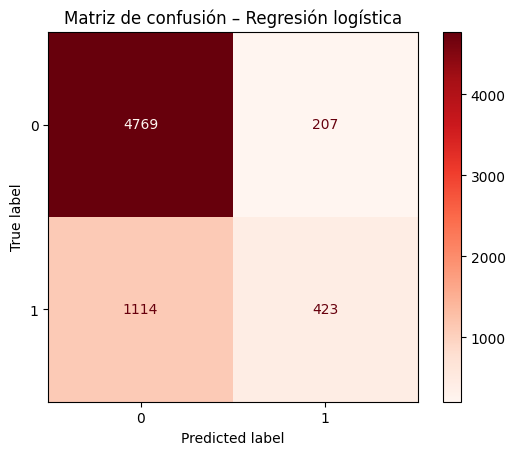

Accuracy:  0.7971748810072163
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      4976
           1       0.67      0.28      0.39      1537

    accuracy                           0.80      6513
   macro avg       0.74      0.62      0.63      6513
weighted avg       0.78      0.80      0.76      6513



In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión – Regresión logística")
plt.show()


# Porcentaje de predicciones que hace bien
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

## 9. Evaluación del modelo
